In [97]:
#Importing Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import ConfusionMatrixDisplay

In [30]:
#Mounting Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
#Loading our dataset
df = pd.read_csv('/content/drive/MyDrive/kaggle/breast-cancer.csv')
df

,Unnamed: 0,Class,Age,Menopause,Tumor-size,Inv-nodes,Node-caps,Deg-malig,Breast,Breast-quad,Irradiat
0,0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
...,...,...,...,...,...,...,...,...,...,...,...
281,281,recurrence-events,30-39,premeno,30-34,0-2,no,2,left,left_up,no
282,282,recurrence-events,30-39,premeno,20-24,0-2,no,3,left,left_up,yes
283,283,recurrence-events,60-69,ge40,20-24,0-2,no,1,right,left_up,no
284,284,recurrence-events,40-49,ge40,30-34,3-5,no,3,left,left_low,no


In [32]:
#Printing dataset shape
df.shape

(286, 11)

In [33]:
#Printing no. of instances and features
print('No. of instances:', df.shape[0])
print('No. of attributes:', df.shape[1])

No. of instances: 286
No. of attributes: 11


In [34]:
#Printing class value
df['Class'].value_counts()

,count
Class,
no-recurrence-events,201
recurrence-events,85


In [35]:
#Checking for missing value
df.isnull().sum()

,0
Unnamed: 0,0
Class,0
Age,0
Menopause,0
Tumor-size,0
Inv-nodes,0
Node-caps,0
Deg-malig,0
Breast,0
Breast-quad,0


In [36]:
#Printing Columns types
df.dtypes

,0
Unnamed: 0,int64
Class,object
Age,object
Menopause,object
Tumor-size,object
Inv-nodes,object
Node-caps,object
Deg-malig,int64
Breast,object
Breast-quad,object


<ipython-input-37-279e8562e1ca>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='rocket')


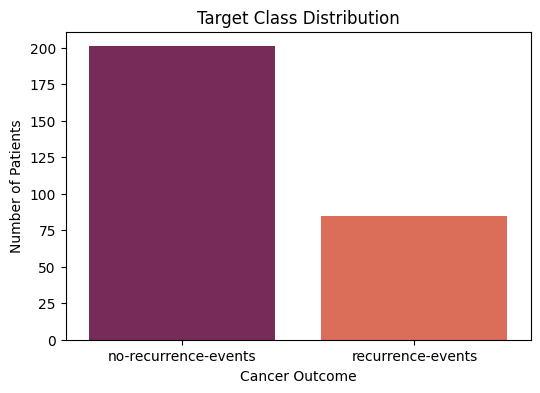

In [37]:
#Visulaizing class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='rocket')
plt.title("Target Class Distribution")
plt.ylabel("Number of Patients")
plt.xlabel("Cancer Outcome")
plt.show()

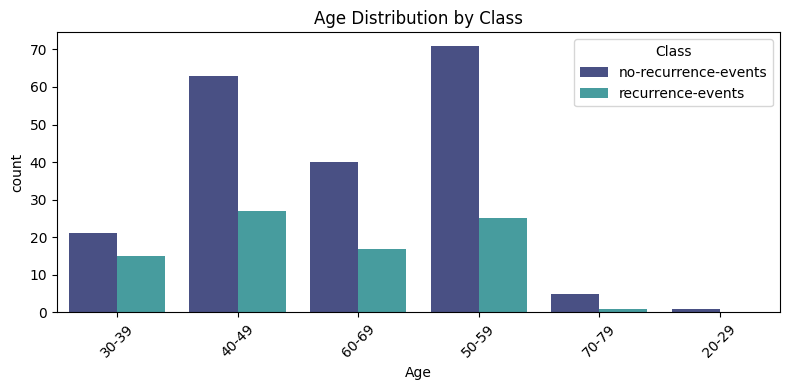

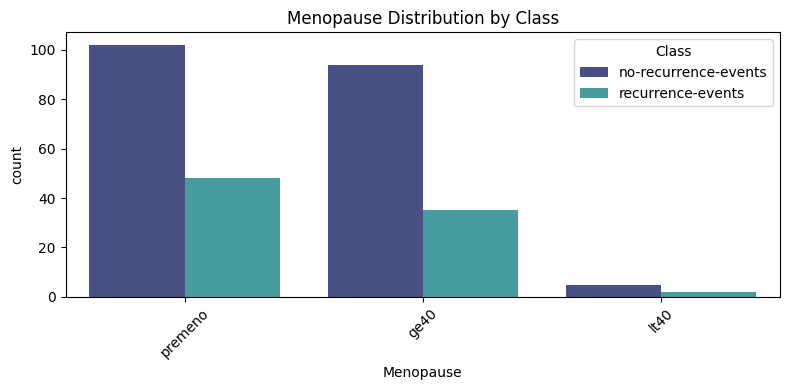

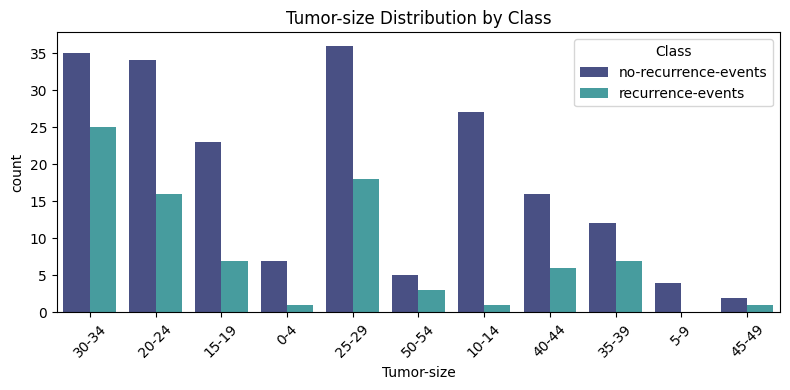

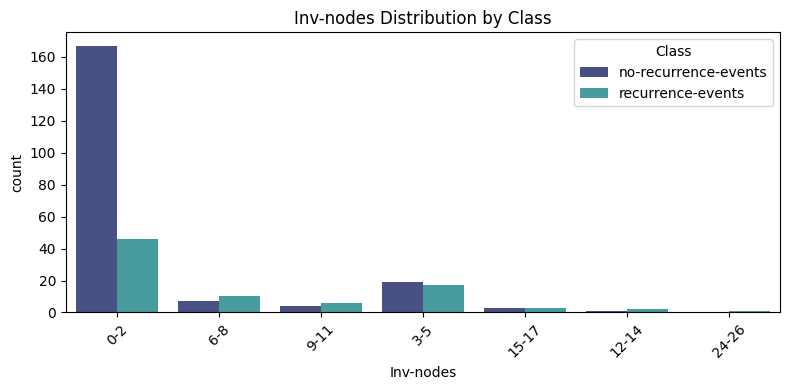

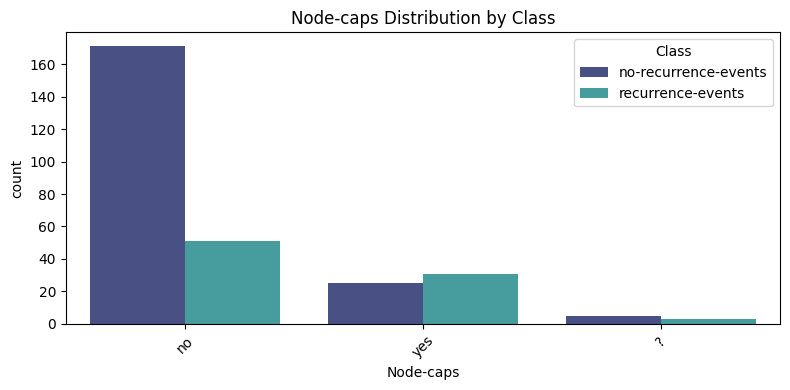

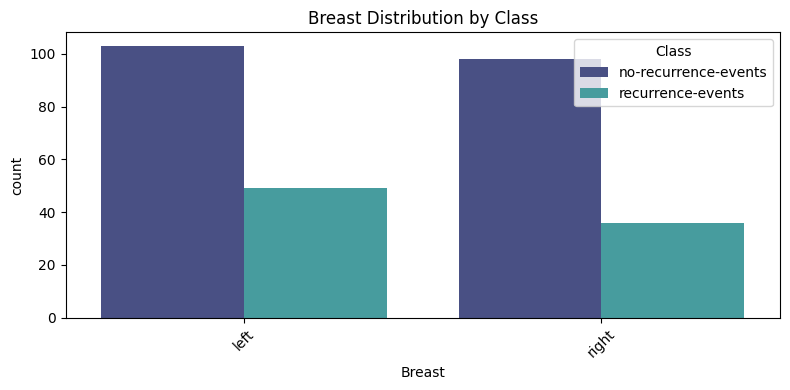

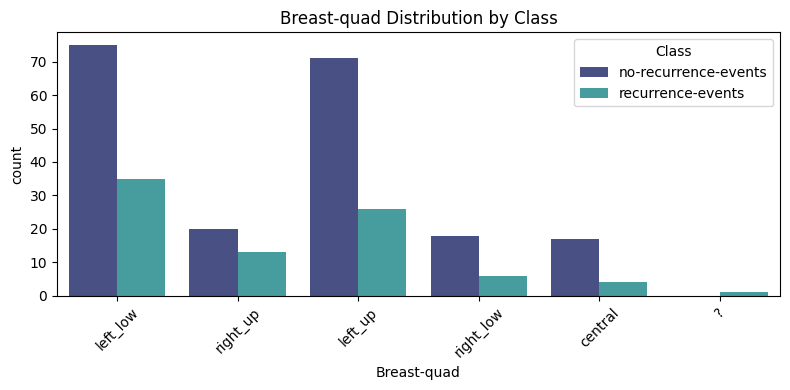

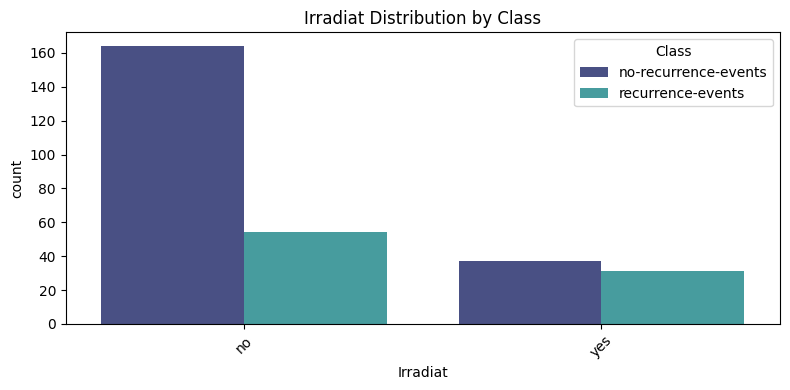

In [38]:
#Visualizing All Categorical Features Split by Target
categorical_features = ['Age', 'Menopause', 'Tumor-size', 'Inv-nodes',
                        'Node-caps', 'Breast', 'Breast-quad', 'Irradiat']

for col in categorical_features:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='Class', palette='mako')
    plt.title(f'{col} Distribution by Class')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [43]:
#Encoding class label
df['Class'] = LabelEncoder().fit_transform(df['Class'])
df['Class'].value_counts()

,count
Class,
0,201
1,85


In [46]:
#One-Hot Encoding on Categorical Features
cat_cols = df.select_dtypes(include='object').columns
if 'Class' in cat_cols:
    cat_cols = cat_cols.drop('Class')

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [47]:
#Splitting dataset in train and test
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
#Fitting Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [95]:
#Evaluation For Random Forest
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9827586206896551
F1 Score: 0.9767441860465116
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99        37
           1       0.95      1.00      0.98        21

    accuracy                           0.98        58
   macro avg       0.98      0.99      0.98        58
weighted avg       0.98      0.98      0.98        58



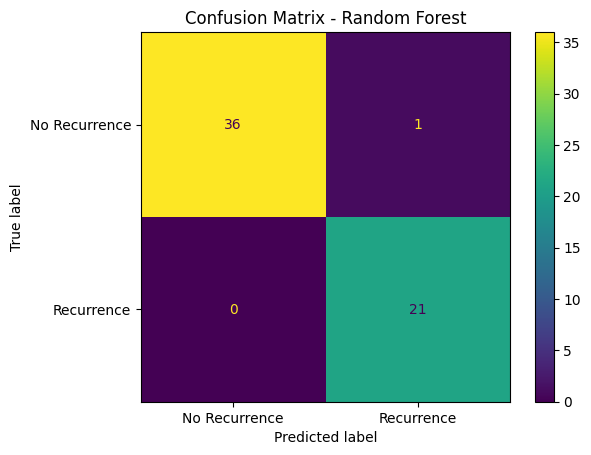

In [93]:
#Plotting confusion matrix
ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test, display_labels=["No Recurrence", "Recurrence"], cmap='viridis')
plt.title("Confusion Matrix - Random Forest")
plt.show()


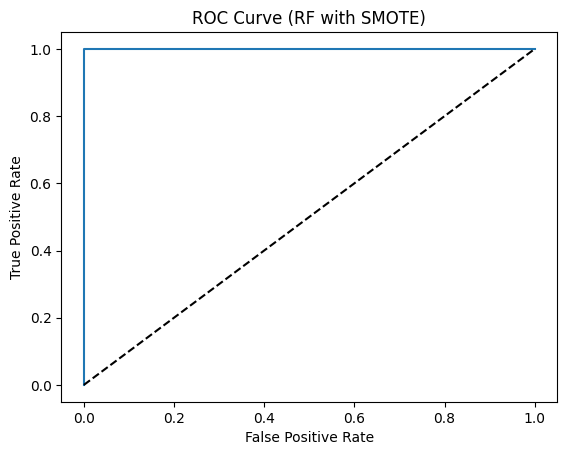

AUC Score: 1.0


In [94]:
#Plotting ROC Curve
probs = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve (RF with SMOTE)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC Score:", roc_auc_score(y_test, probs))


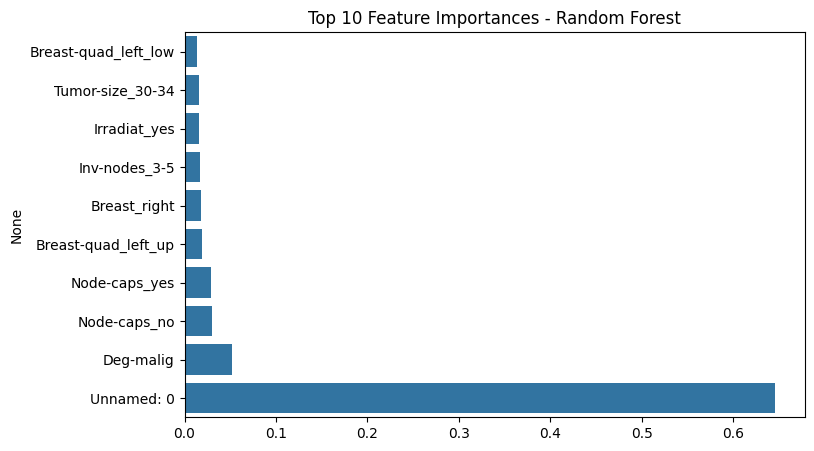

In [88]:
#Important features in our dataset
importances = rf.feature_importances_
indices = np.argsort(importances)[-10:]  #Top 10
features = X.columns[indices]

plt.figure(figsize=(8, 5))
sns.barplot(x=importances[indices], y=features)
plt.title("Top 10 Feature Importances - Random Forest")
plt.show()

Stacking Classifer

In [92]:
#Stacking Classifer
stack = StackingClassifier(
    estimators=[('rf', rf), ('svc', SVC(probability=True))],
    final_estimator=LogisticRegression()
)
stack.fit(X_train, y_train)

StackingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                               ('svc', SVC(probability=True))],
                   final_estimator=LogisticRegression())

In [91]:
y_pred = stack.predict(X_test)

#Evaluation For Stacking
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0
F1 Score: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00        21

    accuracy                           1.00        58
   macro avg       1.00      1.00      1.00        58
weighted avg       1.00      1.00      1.00        58

